# Used Car Price Prediction Dataset

## μLearn Epochs '26 Bootcamp - Day 3

### Exploratory Data Analysis, Data Cleaning & Feature Engineering

Author: Emil Tom Joseph

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("used_cars.csv")

In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.shape

(4009, 12)

In [5]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [7]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe(include="all")

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
for col in ["brand","fuel_type","transmission","accident"]:
    print(f"\n{col}")
    print(df[col].value_counts())


brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4


In [11]:
df["price"] = (
    df["price"]
      .str.replace("$","", regex=False)
      .str.replace(",","", regex=False)
      .astype(float)
)

In [12]:
df["milage"] = (
    df["milage"]
      .str.replace(" mi.","", regex=False)
      .str.replace(",","", regex=False)
      .astype(int)
)

In [13]:
df["fuel_type"] = df["fuel_type"].fillna(df["fuel_type"].mode()[0])
df["accident"] = df["accident"].fillna("Unknown")
df["clean_title"] = df["clean_title"].fillna("Unknown")

In [14]:
current_year = 2026

df["car_age"] = current_year - df["model_year"]

df["mileage_per_year"] = df["milage"] / (df["car_age"] + 1)

premium_brands = [
    "BMW","Mercedes-Benz","Audi","Lexus",
    "Porsche","Land","Tesla","Jaguar"
]

df["is_premium"] = df["brand"].isin(premium_brands).astype(int)

df["has_accident"] = (
    df["accident"]
      .str.contains("None reported", na=False)
      .map({True:0, False:1})
)

df["price_per_year"] = df["price"] / (df["car_age"] + 1)

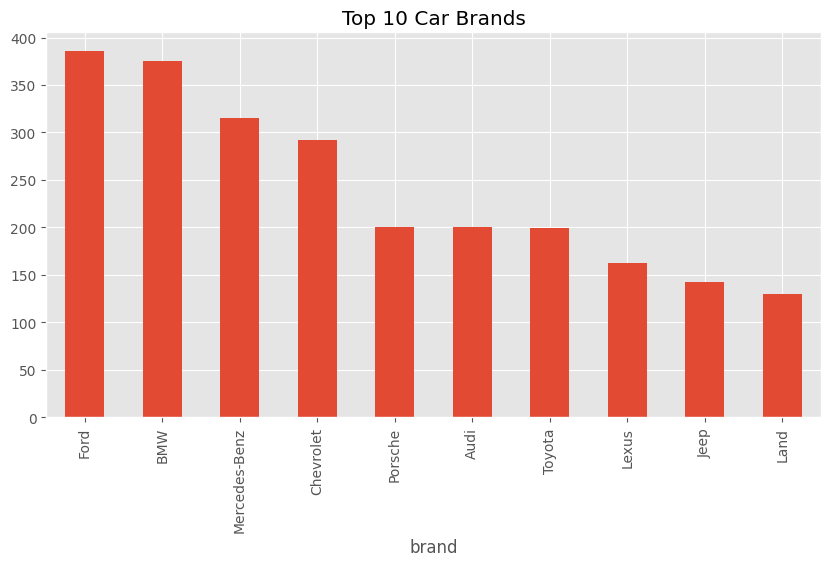

In [15]:
df["brand"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Car Brands")
plt.show()

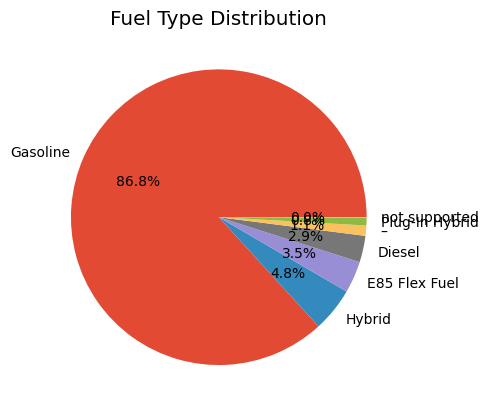

In [16]:
df["fuel_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Fuel Type Distribution")
plt.show()

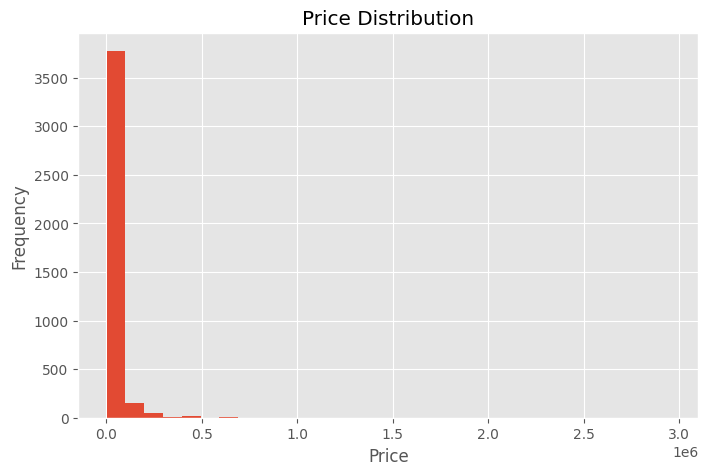

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

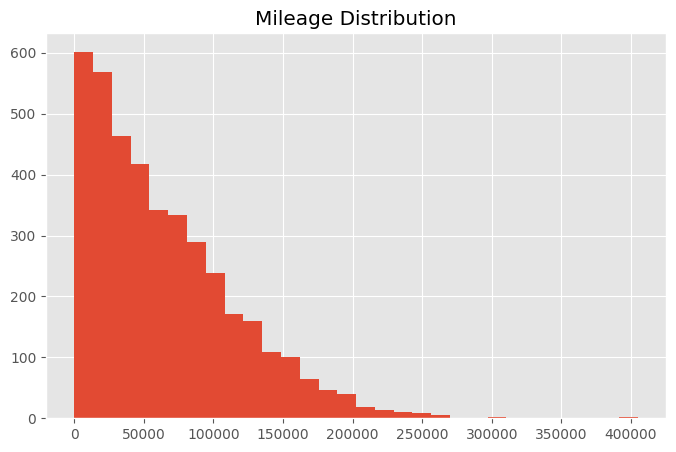

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["milage"], bins=30)

plt.title("Mileage Distribution")

plt.show()

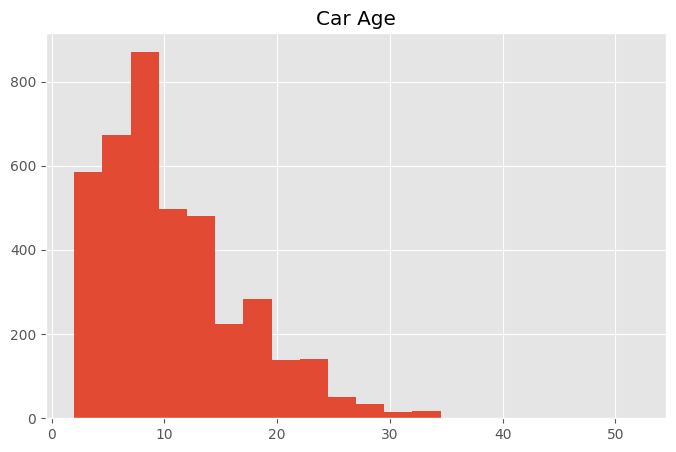

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["car_age"], bins=20)

plt.title("Car Age")

plt.show()

In [20]:
df.to_csv("cleaned_used_cars.csv", index=False)

# Business Insights

### 1.

Luxury brands generally command higher resale prices than economy brands.

### 2.

Most listed vehicles are relatively new, indicating a preference for newer used cars.

### 3.

Mileage is one of the strongest factors influencing vehicle price.

### 4.

A clean vehicle title is common among listed cars, increasing buyer confidence.

### 5.

Feature engineering such as car age and mileage per year can significantly improve future machine learning models.

# Conclusion

This project involved exploring, cleaning, and transforming a real-world used car dataset.

Missing values were handled, duplicate records were removed (if any), incorrect data types were corrected, and five new features were engineered to improve future machine learning performance.

The cleaned dataset is now ready for predictive modeling and price estimation tasks.